In [9]:
!pip install numba cython -q

In [10]:
import numpy as np
import scipy.stats as si
import time
import timeit
import pandas as pd
import matplotlib.pyplot as plt

def black_scholes_call(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = S0 * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
    return price

In [11]:
def mc_pure_python(S0, K, T, r, sigma, n_sim, seed):
    rng = np.random.default_rng(seed)
    payoff_sum = 0.0
    drift = (r - 0.5 * sigma ** 2) * T
    vol = sigma * np.sqrt(T)
    normals = rng.standard_normal(n_sim)
    for i in range(n_sim):
        z = normals[i]
        ST = S0 * np.exp(drift + vol * z)
        payoff = max(ST - K, 0.0)
        payoff_sum += payoff
    price = np.exp(-r * T) * (payoff_sum / n_sim)
    return price

def mc_numpy_vectorized(S0, K, T, r, sigma, n_sim, seed):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n_sim)
    ST = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0.0)
    price = np.exp(-r * T) * np.mean(payoff)
    return price

In [12]:
from numba import jit, prange

@jit(nopython=True, cache=True)
def mc_numba_jit(S0, K, T, r, sigma, n_sim, seed):
    np.random.seed(seed)
    payoff_sum = 0.0
    drift = (r - 0.5 * sigma ** 2) * T
    vol = sigma * np.sqrt(T)
    for i in range(n_sim):
        z = np.random.normal()
        ST = S0 * np.exp(drift + vol * z)
        payoff = max(ST - K, 0.0)
        payoff_sum += payoff
    price = np.exp(-r * T) * (payoff_sum / n_sim)
    return price

@jit(nopython=True, parallel=True, cache=True)
def mc_numba_parallel(S0, K, T, r, sigma, n_sim, seed):
    np.random.seed(seed)
    drift = (r - 0.5 * sigma ** 2) * T
    vol = sigma * np.sqrt(T)
    payoff_sum = 0.0
    for i in prange(n_sim):
        z = np.random.normal()
        ST = S0 * np.exp(drift + vol * z)
        payoff = max(ST - K, 0.0)
        payoff_sum += payoff
    price = np.exp(-r * T) * (payoff_sum / n_sim)
    return price

_ = mc_numba_jit(100.0, 100.0, 1.0, 0.05, 0.2, 100, 42)
_ = mc_numba_parallel(100.0, 100.0, 1.0, 0.05, 0.2, 100, 42)

In [13]:
%load_ext Cython

The Cython extension is already loaded. To reload it, use:
  %reload_ext Cython


In [14]:
%%cython
import cython
from libc.math cimport exp, sqrt, log, cos, M_PI
from libc.stdlib cimport rand, srand, RAND_MAX

cdef inline double uniform01() nogil:
    return (rand() + 1.0) / (RAND_MAX + 2.0)

cdef inline double standard_normal() nogil:
    cdef double u1 = uniform01()
    cdef double u2 = uniform01()
    return sqrt(-2.0 * log(u1)) * cos(2.0 * M_PI * u2)

@cython.boundscheck(False)
@cython.wraparound(False)
@cython.cdivision(True)
def mc_cython(double S0, double K, double T, double r, double sigma, long n_sim, unsigned int seed):
    cdef long i
    cdef double payoff_sum = 0.0
    cdef double drift = (r - 0.5 * sigma * sigma) * T
    cdef double vol = sigma * sqrt(T)
    cdef double z, ST, payoff

    srand(seed)
    for i in range(n_sim):
        z = standard_normal()
        ST = S0 * exp(drift + vol * z)
        payoff = ST - K
        if payoff < 0:
            payoff = 0.0
        payoff_sum += payoff
    return exp(-r * T) * (payoff_sum / n_sim)

In [15]:
S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.2
SEED = 42
bs_price = black_scholes_call(S0, K, T, r, sigma)

N_MAIN = 1_000_000
N_PURE_PYTHON = 100_000

methods = {
    "Pure Python": (lambda: mc_pure_python(S0, K, T, r, sigma, N_PURE_PYTHON, SEED), N_PURE_PYTHON),
    "NumPy Vectorized": (lambda: mc_numpy_vectorized(S0, K, T, r, sigma, N_MAIN, SEED), N_MAIN),
    "Numba JIT": (lambda: mc_numba_jit(S0, K, T, r, sigma, N_MAIN, SEED), N_MAIN),
    "Numba Parallel": (lambda: mc_numba_parallel(S0, K, T, r, sigma, N_MAIN, SEED), N_MAIN),
    "Cython": (lambda: mc_cython(S0, K, T, r, sigma, N_MAIN, SEED), N_MAIN),
}

results = []
TOLERANCE = 0.15
assertion_failures = []

for name, (func, n_sim) in methods.items():
    times = timeit.repeat(func, repeat=5, number=1)
    price = func()

    if abs(price - bs_price) >= TOLERANCE:
        assertion_failures.append(name)

    rng = np.random.default_rng(SEED)
    Z = rng.standard_normal(n_sim)
    ST = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)
    payoffs = np.exp(-r * T) * np.maximum(ST - K, 0.0)
    std_error = np.std(payoffs) / np.sqrt(n_sim)
    ci_low, ci_high = price - 1.96 * std_error, price + 1.96 * std_error

    results.append({
        "Method": name,
        "N_Simulations": n_sim,
        "Median Time (s)": np.median(times),
        "Std Dev (s)": np.std(times),
        "Calculated Price": price,
        "Error vs BS": abs(price - bs_price),
        "Std Error": std_error,
        "95% CI Low": ci_low,
        "95% CI High": ci_high,
    })

assert not assertion_failures, f"Convergence check FAILED for: {assertion_failures}"
print("All methods converged to the Black-Scholes price within tolerance.\n")

df = pd.DataFrame(results)

baseline_time = df.loc[df["Method"] == "Pure Python", "Median Time (s)"].values[0]
baseline_time_scaled = baseline_time * (N_MAIN / N_PURE_PYTHON)
df["Speedup Factor"] = baseline_time_scaled / df["Median Time (s)"]

print(f"Black-Scholes Analytical Price: {bs_price:.4f}")
df

All methods converged to the Black-Scholes price within tolerance.

Black-Scholes Analytical Price: 10.4506


,Method,N_Simulations,Median Time (s),Std Dev (s),Calculated Price,Error vs BS,Std Error,95% CI Low,95% CI High,Speedup Factor
0,Pure Python,100000,0.221828,0.047220,10.420541,0.030042,0.046770,10.328873,10.512210,10.000000
1,NumPy Vectorized,1000000,0.028677,0.003043,10.453195,0.002612,0.014731,10.424322,10.482069,77.353682
2,Numba JIT,1000000,0.053042,0.003808,10.434158,0.016426,0.014731,10.405284,10.463031,41.821495
3,Numba Parallel,1000000,0.045602,0.004849,10.449731,0.000852,0.014731,10.420857,10.478605,48.644300
4,Cython,1000000,0.180163,0.044334,10.432377,0.018206,0.014731,10.403504,10.461251,12.312650


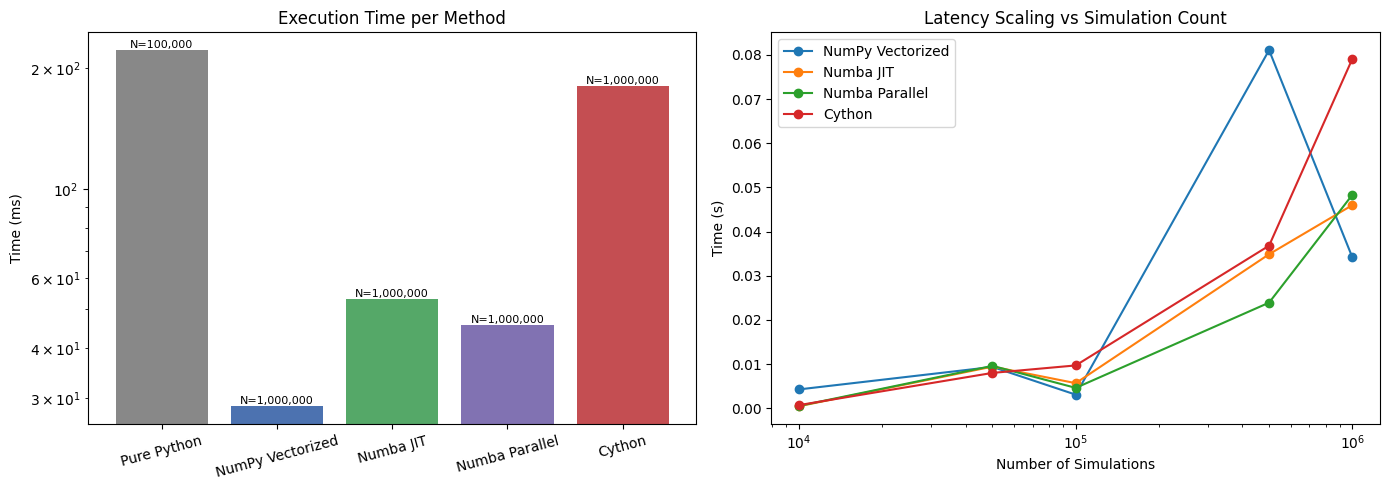

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#888888", "#4C72B0", "#55A868", "#8172B2", "#C44E52"]
bars = axes[0].bar(df["Method"], df["Median Time (s)"] * 1000, color=colors[:len(df)])
axes[0].set_ylabel("Time (ms)")
axes[0].set_title("Execution Time per Method")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=15)
for bar, n_sim in zip(bars, df["N_Simulations"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f"N={n_sim:,}", ha="center", va="bottom", fontsize=8)

n_values = [10_000, 50_000, 100_000, 500_000, 1_000_000]
scaling_results = {name: [] for name in ["NumPy Vectorized", "Numba JIT", "Numba Parallel", "Cython"]}
for n in n_values:
    scaling_results["NumPy Vectorized"].append(
        timeit.timeit(lambda: mc_numpy_vectorized(S0, K, T, r, sigma, n, SEED), number=1))
    scaling_results["Numba JIT"].append(
        timeit.timeit(lambda: mc_numba_jit(S0, K, T, r, sigma, n, SEED), number=1))
    scaling_results["Numba Parallel"].append(
        timeit.timeit(lambda: mc_numba_parallel(S0, K, T, r, sigma, n, SEED), number=1))
    scaling_results["Cython"].append(
        timeit.timeit(lambda: mc_cython(S0, K, T, r, sigma, n, SEED), number=1))

for name, times in scaling_results.items():
    axes[1].plot(n_values, times, marker='o', label=name)
axes[1].set_xlabel("Number of Simulations")
axes[1].set_ylabel("Time (s)")
axes[1].set_title("Latency Scaling vs Simulation Count")
axes[1].legend()
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()


